# Analytic Heat Redistribution Testing

In [1]:
import os, sys
#sys.path.append('/Users/btl756/Desktop/caroline/picaso')
#sys.path.append('/Users/btl756/Desktop/caroline/virga')
#os.environ['picaso_refdata'] = '/Users/btl756/Desktop/caroline/picaso/reference' #THIS MUST GO BEFORE YOUR IMPORT STATEMENT
#os.environ['PYSYN_CDBS'] = '/Users/btl756/Desktop/caroline/picaso/grp/redcat/trds' #this is for the stellar data discussed below.
import picaso.justdoit as jdi

import warnings
warnings.filterwarnings('ignore')
import picaso.justdoit as jdi
import picaso.justplotit as jpi
import virga.justdoit as vj
import virga.justplotit as cldplt
from bokeh.plotting import show, figure
jpi.output_notebook()
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.io import ascii
import copy
import pandas as pd
%matplotlib inline
#mpl.rc_file('/Users/btl756/Desktop/caroline/liberles_rc')

Loading BokehJS ...

## Create a CO2 profile

First let's create a custom 100% CO2 chemistry profile that we can use to make a "Venus" analog

In [2]:
# start with grabbing one of channon's chemistry files
channon = ascii.read(os.path.join(os.environ['picaso_refdata'] ,'chemistry/visscher_grid_2121/sonora_2121grid_feh-0.3_co0.14.txt'))

# change compositions in the grabbed file to match 100% CO2 atmosphere
co2_pt_temp = copy.deepcopy(channon)

# cycle through all levels in the atmosphere
for i in range(len(channon['P(bar)'])):    
    for col in channon.colnames:
        if col not in ['P(bar)', 'T(K)']: # only want to change the composition columns
            if col != 'CO2': co2_pt_temp[col][[i]] = 1e-50 # set all compositions to zero except CO2; 1e-50 to avoid division by zero errors

    # update CO2 compostion column
    co2_pt_temp['CO2'][i] = 1

# clean up formatting of our new CO2 PT profile
co2_pt = co2_pt_temp.to_pandas()
co2_pt = co2_pt.rename(columns={'P(bar)': 'pressure', 'T(K)': 'temperature', 'atCs': 'Cs'})
co2_pt['pressure'] = 10**co2_pt['pressure']
co2_pt

,temperature,pressure,e-,H2,H,H+,H-,H2-,H2+,H3+,...,LiF,C,O,Mg,Mg+,Si,Fe+,Ti,Ti+,C+
0,75.0,0.000001,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50
1,75.0,0.000003,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50
2,75.0,0.000010,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50
3,75.0,0.000030,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50
4,75.0,0.000100,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,6000.0,100.000000,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50
2117,6000.0,299.916252,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50
2118,6000.0,1000.000000,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50
2119,6000.0,2999.162519,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,...,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50,1.000000e-50


## Load opacities

In [3]:
# set up on-the-fly opacities
import os;import glob
[i.split('/')[-1].split("_")[0] for i in glob.glob(
    os.path.join(os.environ['picaso_refdata'],'climate_INPUTS','ktable_by_molecule','*npy')
)]
#should see a list of molecules (ie. ['H3+', 'FeH', 'C2H2'....])

#gases_fly = ['CO','CH4','H2O','NH3','CO2','N2','HCN','H2','He','PH3','C2H2','Na','K','TiO','VO','FeH']
gases_fly = ['CO2']
opacity_fly = jdi.opannection(method='resortrebin', preload_gases=gases_fly)
#opacity_fly.full_abunds = co2_pt # set the abundances to the CO2 profile

## Run a planet with constant rfacv (the old way with no changes to the code)

In [ ]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260#110 # Intrinsic Temperature in K; inputting venus equilibrium temperature
grav = 8.87#24.79 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

# now let's input host-star properties
T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723#5.2 # star planet distance, AU

cl_run.star(opacity_fly, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# make an initial T(P) guess
nlevel = 91 # number of plane-parallel levels in your code

Teq = 260#122 # venus equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

# make assumptions for surface reflectance
albedo = 0.75 # assume some albedo to set surface properties
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1)) # not currently compatible with on-the-fly opacities

# initial convective zones guess
nofczns = 1 # number of convective zones initially. Let's not play with this for now.

nstr_upper = 74 # top most level of guessed convective zone
nstr_deep = nlevel -2 # this is always the case. Dont change this
nstr = np.array([0,nstr_upper,nstr_deep,0,0,0]) # initial guess of convective zones

rfacv = 0.5

# gather inputs for our climate run
cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      rcb_guess=74, rfacv=rfacv)

# prepare opacities for on-the-fly mixing
#exclude_mol = ['CO','CH4','H2O','NH3','N2','HCN','H2','He','PH3','C2H2','Na','K','TiO','VO','FeH']
#cl_run.chemistry_handler(chemistry_table=co2_pt)

pt['CO2']=1.0
pt['H2']=1e-50
cl_run.atmosphere(df=pt, chem_method='fixed',quench=False)
#cl_run.premix_atmosphere(opa=opacity_fly)

# run the climate code!
out_const_rfacv = cl_run.climate(opacity_fly, save_all_profiles=True, with_spec=True, diseq_chem=False)#DISEQ HERE TO CHANGE! 

SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
CHEMMETHOD fixed
HELLOO
    temperature      pressure  CO2            H2
0    263.194008      0.000001    1  1.000000e-50
1    263.194951      0.000001    1  1.000000e-50
2    263.196165      0.000002    1  1.000000e-50
3    263.197729      0.000002    1  1.000000e-50
4    263.199741      0.000003    1  1.000000e-50
..          ...           ...  ...           ...
86  4145.472604   3593.813664    1  1.000000e-50
87  4338.067164   4641.588834    1  1.000000e-50
88  4539.609476   5994.842503    1  1.000000e-50
89  4750.515244   7742.636827    1  1.000000e-50
90  4971.219487  10000.000000    1  1.000000e-50

[91 rows x 4 columns]


ValueError: cannot compute fingerprint of empty list

Analyze output in xarray

In [ ]:
preserve_clima_const_rfacv = jdi.output_xarray(out_const_rfacv, cl_run)
preserve_clima_const_rfacv

<xarray.Dataset> Size: 110kB
Dimensions:         (pressure: 91, pressure_layer: 90, wavelength: 661)
Coordinates:
  * pressure        (pressure) float64 728B 1e-06 1.292e-06 ... 7.743e+03 1e+04
  * wavelength      (wavelength) float64 5kB 267.6 197.9 154.9 ... 0.287 0.2679
  * pressure_layer  (pressure_layer) float64 720B 1.136e-06 ... 8.799e+03
Data variables: (12/136)
    temperature     (pressure) float64 728B 243.1 235.3 ... 1.512e+03 1.62e+03
    dtdp            (pressure_layer) float64 720B -0.1271 -0.1389 ... 0.2718
    guess 1         (pressure) float64 728B 263.2 263.2 ... 5.548e+03 5.915e+03
    guess 2         (pressure) float64 728B 263.2 263.2 ... 4.751e+03 4.971e+03
    guess 3         (pressure) float64 728B 263.2 263.2 ... 4.751e+03 4.971e+03
    guess 4         (pressure) float64 728B 261.5 261.3 ... 4.72e+03 4.939e+03
    ...              ...
    Mg+             (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    Si              (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    Fe+             (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    Ti              (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    Ti+             (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    C+              (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
Attributes:
    climate_params:  {"cvs_locs": [0, 65, 67, 67, 74, 89], "converged": 1}
    planet_params:   {"effective_temp": 302.1945733618051, "gravity": {"value...
    stellar_params:  {"database": "phoenix", "steff": 5800, "feh": 0.012, "lo...
    orbit_params:    {"sma": {"value": 10815926051610.0, "unit": "cm"}}

Plot PT profile

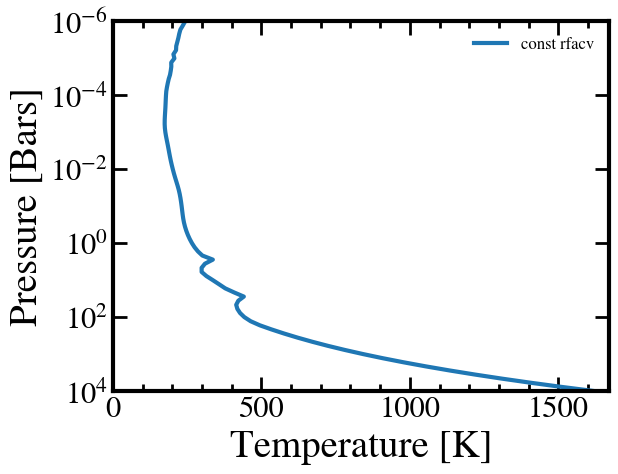

In [6]:
plt.semilogy(out_const_rfacv['temperature'], out_const_rfacv['pressure'],linewidth=3,label="const rfacv")

plt.ylabel("Pressure [Bars]")
plt.xlabel('Temperature [K]')
plt.ylim(1e4,1e-6)
plt.xlim(0, out_const_rfacv['temperature'].max() + 50)
plt.legend()

Check the brightness temperature

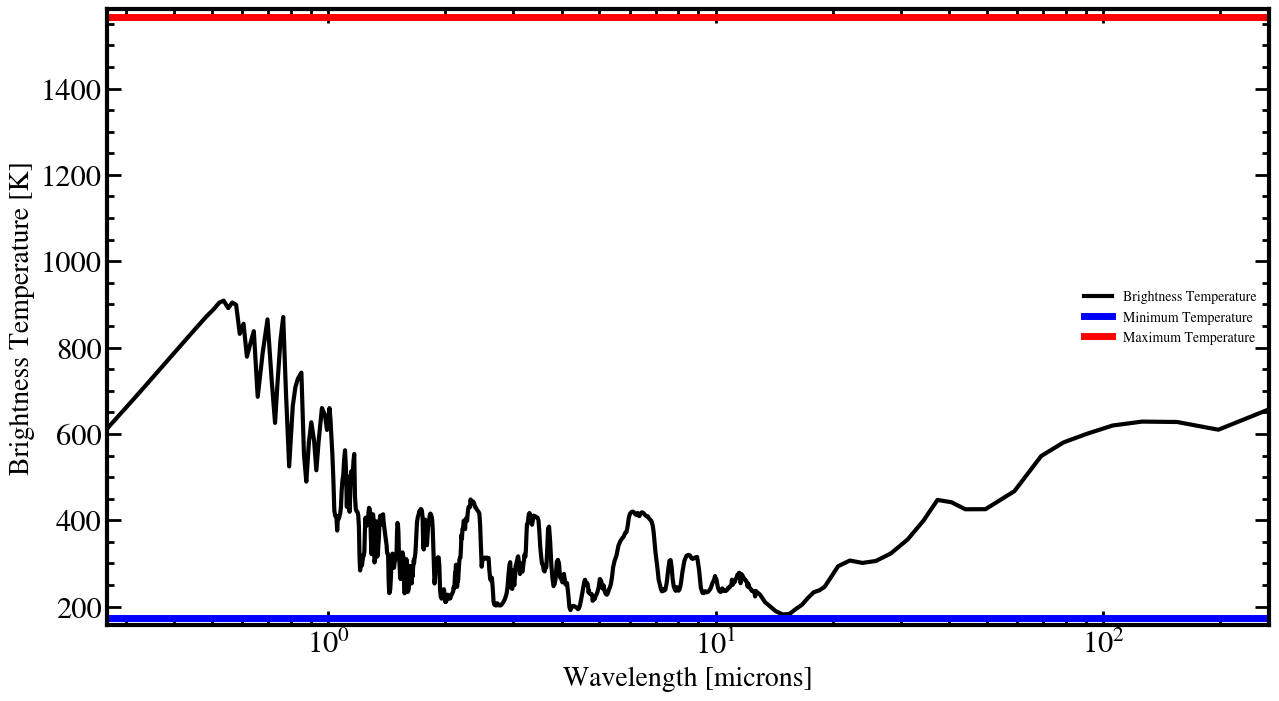

In [7]:
brightness_temp, figure= jpi.brightness_temperature(out_const_rfacv['spectrum_output'])

Evaluate the adiabat

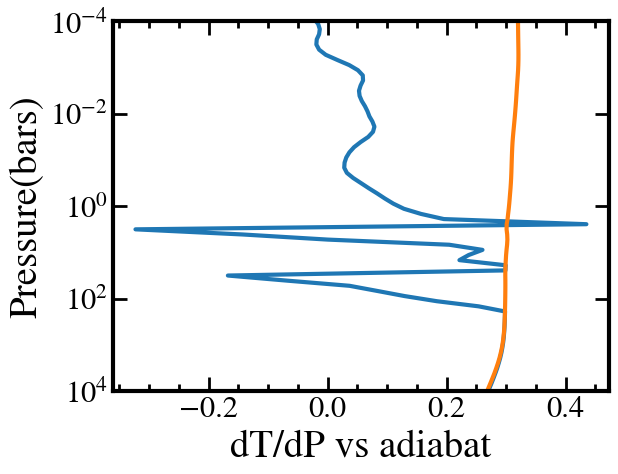

In [8]:
cp, adiabat, dtdp, pressure = jpi.pt_adiabat(out_const_rfacv, cl_run, opacity_fly, plot=True)
# blue is dT/dP, orange is the gradient of the adiabat

## Run a planet with analytic heat redistribution (involving the new changes to the code)

The only difference between the cell below and what was run for the old code case above is setting rfacv = 'analytic'

In [9]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260#110 # Intrinsic Temperature in K; inputting venus equilibrium temperature
grav = 8.87#24.79 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

# now let's input host-star properties
T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723#5.2 # star planet distance, AU

cl_run.star(opacity_fly, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# make an initial T(P) guess
nlevel = 91 # number of plane-parallel levels in your code

Teq = 260#122 # venus equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

# make assumptions for surface reflectance
albedo = 0.75 # assume some albedo to set surface properties
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1)) # not currently compatible with on-the-fly opacities

# initial convective zones guess
nofczns = 1 # number of convective zones initially. Let's not play with this for now.

nstr_upper = 74 # top most level of guessed convective zone
nstr_deep = nlevel -2 # this is always the case. Dont change this
nstr = np.array([0,nstr_upper,nstr_deep,0,0,0]) # initial guess of convective zones

rfacv = 'analytic' # set rfacv to analytic to enable analytic heat redistribution

# gather inputs for our climate run
cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      nstr=nstr, nofczns=nofczns, rfacv=rfacv)

# prepare opacities for on-the-fly mixing
exclude_mol = ['CO','CH4','H2O','NH3','N2','HCN','H2','He','PH3','C2H2','Na','K','TiO','VO','FeH']

cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_fly)

# run the climate code!
out_analytic_rfacv = cl_run.climate(opacity_fly, save_all_profiles=True, with_spec=True, diseq_chem=True)

SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
I am updating kzz. This could be either because clouds were requested (which always use self consistent kzz) or because self consistent kzz profiles were requested for chemistry.
I dont have fluxes, let me compute them
Computed quenched levels at {'CO-CH4-H2O': 69, 'CO2': 64, 'NH3-N2': 70, 'HCN': 68}
Iteration number  0 , min , max temp  259.6566011337486 4939.4774417190965 , flux balance  88.08203811469215
Iteration number  1 , min , max temp  204.27050183247434 4451.870343253877 , flux balance  29.709094832191017
Iteration number  2 , min , max temp  179.75759182678974 4073.754933667685 , flux balance  9.888536113742713
Iteration number  3 , min , max temp  165.55780937655808 3761.3963357145294 , flux balance  3.154069111511352
Iteration number  4 , min , max temp  99.34506617992596 3490.7737902487515 , flux balance  0.9376901247529861
Iteration number  5 , min , max temp  1

Analyze output in xarray

In [10]:
preserve_clima_analytic_rfacv = jdi.output_xarray(out_analytic_rfacv, cl_run)
preserve_clima_analytic_rfacv

<xarray.Dataset> Size: 105kB
Dimensions:         (pressure: 91, pressure_layer: 90, wavelength: 661)
Coordinates:
  * pressure        (pressure) float64 728B 1e-06 1.292e-06 ... 7.743e+03 1e+04
  * wavelength      (wavelength) float64 5kB 267.6 197.9 154.9 ... 0.287 0.2679
  * pressure_layer  (pressure_layer) float64 720B 1.136e-06 ... 8.799e+03
Data variables: (12/129)
    temperature     (pressure) float64 728B 244.7 238.0 ... 1.511e+03 1.62e+03
    dtdp            (pressure_layer) float64 720B -0.1083 -0.2183 ... 0.2718
    guess 1         (pressure) float64 728B 263.2 263.2 ... 5.548e+03 5.915e+03
    guess 2         (pressure) float64 728B 263.2 263.2 ... 4.751e+03 4.971e+03
    guess 3         (pressure) float64 728B 263.2 263.2 ... 4.751e+03 4.971e+03
    guess 4         (pressure) float64 728B 261.5 261.3 ... 4.72e+03 4.939e+03
    ...              ...
    Mg+             (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    Si              (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    Fe+             (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    Ti              (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    Ti+             (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
    C+              (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
Attributes:
    climate_params:  {"cvs_locs": [0, 65, 67, 67, 74, 89], "converged": 1}
    planet_params:   {"effective_temp": 302.2426810905375, "gravity": {"value...
    stellar_params:  {"database": "phoenix", "steff": 5800, "feh": 0.012, "lo...
    orbit_params:    {"sma": {"value": 10815926051610.0, "unit": "cm"}}

Plot PT profile

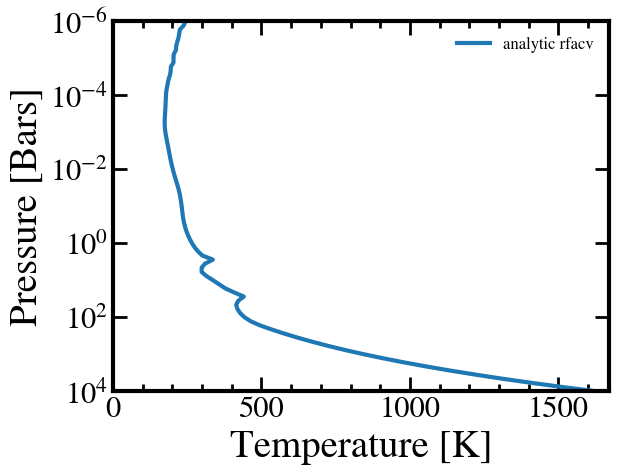

In [11]:
plt.semilogy(out_analytic_rfacv['temperature'], out_analytic_rfacv['pressure'],linewidth=3,label="analytic rfacv")

plt.ylabel("Pressure [Bars]")
plt.xlabel('Temperature [K]')
plt.ylim(1e4,1e-6)
plt.xlim(0, out_analytic_rfacv['temperature'].max() + 50)
plt.legend()

Check the brightness temperature

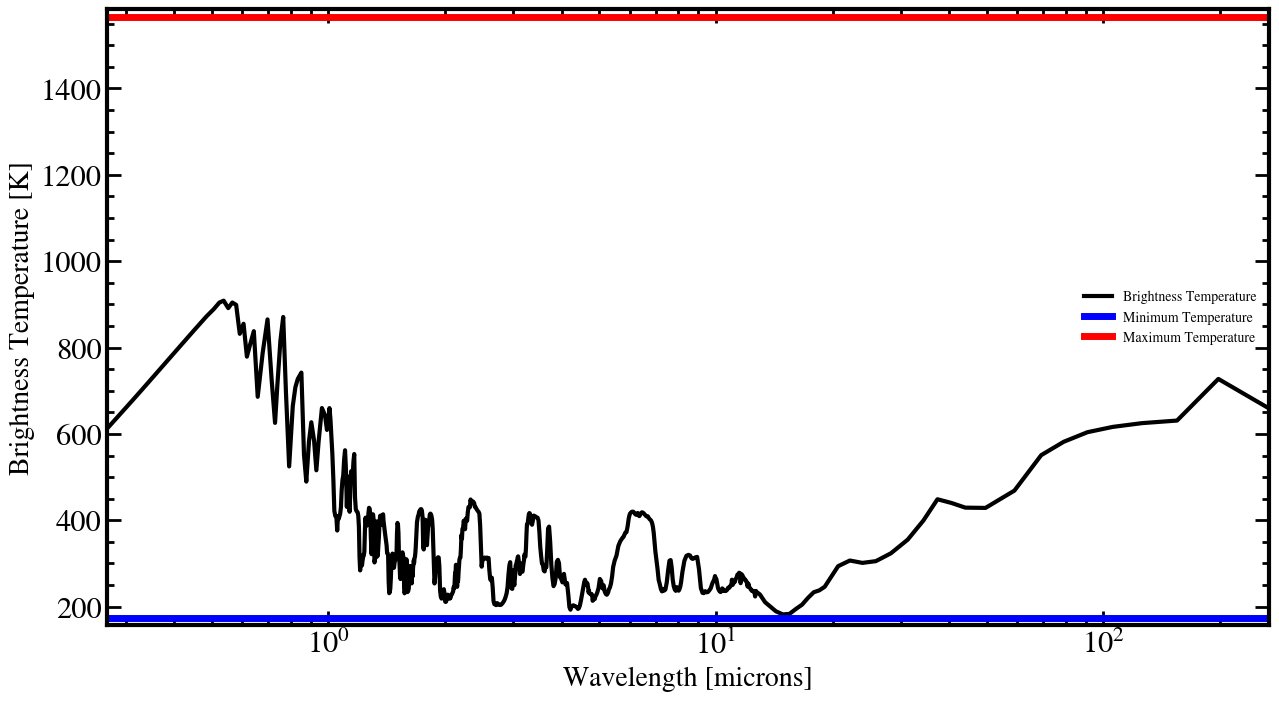

In [12]:
brightness_temp, figure= jpi.brightness_temperature(out_analytic_rfacv['spectrum_output'])

Evaluate the adiabat

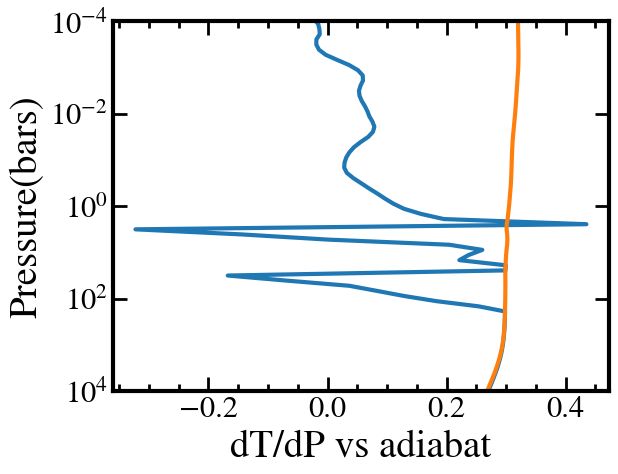

In [13]:
cp, adiabat, dtdp, pressure = jpi.pt_adiabat(out_analytic_rfacv, cl_run, opacity_fly, plot=True)
# blue is dT/dP, orange is the gradient of the adiabat

Compare PT Profiles

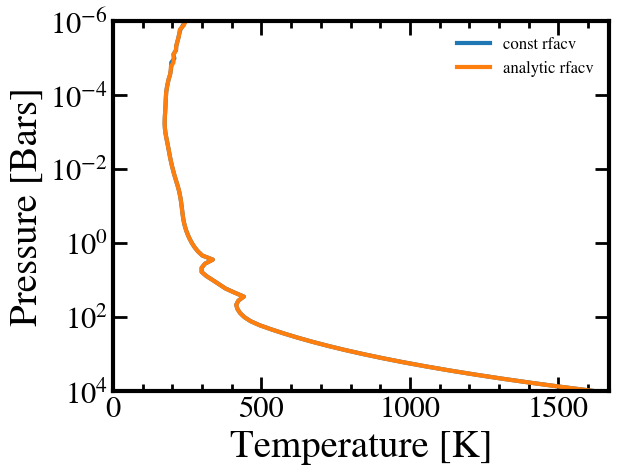

In [14]:
plt.semilogy(out_const_rfacv['temperature'], out_const_rfacv['pressure'], label="const rfacv")
plt.semilogy(out_analytic_rfacv['temperature'], out_analytic_rfacv['pressure'], label="analytic rfacv")

plt.ylabel("Pressure [Bars]")
plt.xlabel('Temperature [K]')
plt.ylim(1e4,1e-6)
plt.xlim(0, out_analytic_rfacv['temperature'].max() + 50)
plt.legend()

Let's take a look at the rfacv values

In [15]:
out_analytic_rfacv['all_rfacv']

array([0.50000003, 0.50000003, 0.50000003, 0.50000003, 0.50000003,
       0.50000003, 0.50000003, 0.50000003, 0.50000003, 0.50000003,
       0.50000003, 0.50000003, 0.50000003, 0.50000003, 0.50000003,
       0.50000003, 0.50000003, 0.50000003, 0.50000003, 0.50000003])

Text(0, 0.5, '$f$')

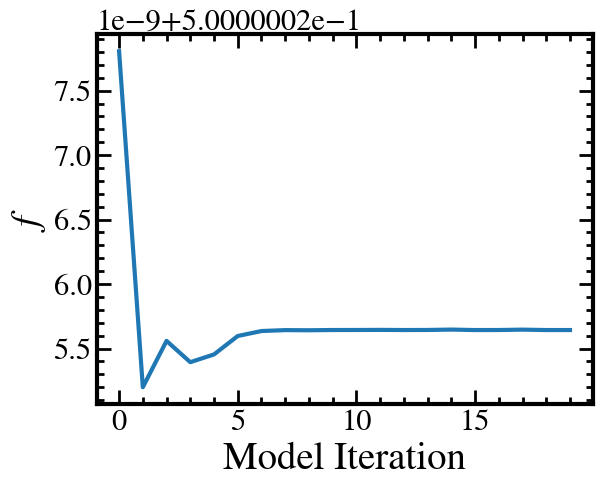

In [16]:
# plot the evolution of rfacv over the model run
all_rfacv = out_analytic_rfacv['all_rfacv']
x = np.arange(0, len(all_rfacv), 1)
plt.plot(x, all_rfacv)
plt.xlabel('Model Iteration')
plt.ylabel('$f$')

## Let's verify that the code will advise the user what to do if they don't specify a star with analytic rfacv

In [17]:
cl_run = jdi.inputs(calculation="browndwarf", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260#110 # Intrinsic Temperature in K; inputting venus equilibrium temperature
grav = 8.87#24.79 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

# now let's input host-star properties
'''
T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723#5.2 # star planet distance, AU

cl_run.star(opacity_fly, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)
'''

# make an initial T(P) guess
nlevel = 91 # number of plane-parallel levels in your code

Teq = 260#122 # venus equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

# make assumptions for surface reflectance
albedo = 0.75 # assume some albedo to set surface properties
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1)) # not currently compatible with on-the-fly opacities

# initial convective zones guess
nofczns = 1 # number of convective zones initially. Let's not play with this for now.

nstr_upper = 81 # top most level of guessed convective zone
nstr_deep = nlevel -2 # this is always the case. Dont change this
nstr = np.array([0,nstr_upper,nstr_deep,0,0,0]) # initial guess of convective zones

rfacv = 'analytic' # set rfacv to analytic to enable analytic heat redistribution

# gather inputs for our climate run
cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      nstr=nstr, nofczns=nofczns, rfacv=rfacv)

# prepare opacities for on-the-fly mixing
exclude_mol = ['CO','CH4','H2O','NH3','N2','HCN','H2','He','PH3','C2H2','Na','K','TiO','VO','FeH']

cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_fly)

# run the climate code!
out_analytic_rfacv = cl_run.climate(opacity_fly, save_all_profiles=True, with_spec=True, diseq_chem=True)

Exception: Analytic heat redistribution is not available if there is no star. Please set up star with jdi.inputs.star() or change rfacv.

## Preweighted Opacities + Surface

In [18]:
# first grab ck table from roxana
mh = '+000'# Solar
CtoO = '100'# Solar C/O ratio
ck_db = f'/Users/btl756/Desktop/caroline/picaso/reference/correlated_k/5590989/sonora_2020_feh{mh}_co_{CtoO}.data.196'

# set up correlated-k opacities
opacity_ck = jdi.opannection(ck_db=ck_db, method='preweighted', preload_gases=['CO2']) # grab your opacities
opacity_ck.full_abunds = co2_pt # set the abundances to the CO2 profile

Run climate model for constant rfacv, preweighted opacities, and no surface

In [19]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260 # Intrinsic Temperature in K
grav = 8.87 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723 # star planet distance, AU

cl_run.star(opacity_ck, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# assume some albedo to set surface properties
albedo = 0.75
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1))

nlevel = 91 # number of plane-parallel levels in your code

#Lets set the max and min at 1e-4 bars and 500 bars
Teq = 260 # equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

nofczns = 1 # number of convective zones initially. Let's not play with this for now.

nstr_upper = 81 # top most level of guessed convective zone
nstr_deep = nlevel -2 # this is always the case. Dont change this
nstr = np.array([0,nstr_upper,nstr_deep,0,0,0]) # initial guess of convective zones

rfacv = 0.5

cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      nstr=nstr, nofczns=nofczns , rfacv=rfacv)

# prep chemistry and opacities
cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_ck)

out_const_rfacv_preweighted = cl_run.climate(opacity_ck, save_all_profiles=True, with_spec=True)

SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
Iteration number  0 , min , max temp  262.8133629660917 5184.848220178808 , flux balance  14.037495426397365
Iteration number  1 , min , max temp  228.82323359628387 5199.9 , flux balance  3.94256151978855
Iteration number  2 , min , max temp  204.53311223464289 5199.9 , flux balance  0.8463219905586303
Iteration number  3 , min , max temp  211.98402802075142 5199.9 , flux balance  0.09046838537483008
Iteration number  4 , min , max temp  212.0332577379428 5199.9 , flux balance  0.002975250446494006
Iteration number  5 , min , max temp  212.03813968175373 5199.9 , flux balance  4.671656770916352e-05
In t_start: Converged Solution in iterations  5
Big iteration is  212.03813968175373 0
Iteration number  0 , min , max temp  212.03814603280165 5199.9 , flux balance  4.522635694184001e-05
In t_start: Converged Solution in iterations  0
Profile converged before itmx
Iteration numbe

Run climate model for constant rfacv, preweighted opacities, and a surface

In [20]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260 # Intrinsic Temperature in K
grav = 8.87 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723 # star planet distance, AU

cl_run.star(opacity_ck, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# assume some albedo to set surface properties
albedo = 0.75
cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1))

nlevel = 91 # number of plane-parallel levels in your code

#Lets set the max and min at 1e-4 bars and 500 bars
Teq = 260 # equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

nofczns = 1 # number of convective zones initially. Let's not play with this for now.

nstr_upper = 81 # top most level of guessed convective zone
nstr_deep = nlevel -2 # this is always the case. Dont change this
nstr = np.array([0,nstr_upper,nstr_deep,0,0,0]) # initial guess of convective zones

rfacv = 0.5

cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      nstr=nstr, nofczns=nofczns , rfacv=rfacv)

# prep chemistry and opacities
cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_ck)

out_const_rfacv_preweighted_surface = cl_run.climate(opacity_ck, save_all_profiles=True, with_spec=True)

SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
Iteration number  0 , min , max temp  262.8133629660917 5184.848220178808 , flux balance  14.037495426397365
Iteration number  1 , min , max temp  228.82323359628387 5199.9 , flux balance  3.94256151978855
Iteration number  2 , min , max temp  204.53311223464289 5199.9 , flux balance  0.8463219905586303
Iteration number  3 , min , max temp  211.98402802075142 5199.9 , flux balance  0.09046838537483008
Iteration number  4 , min , max temp  212.0332577379428 5199.9 , flux balance  0.002975250446494006
Iteration number  5 , min , max temp  212.03813968175373 5199.9 , flux balance  4.671656770916352e-05
In t_start: Converged Solution in iterations  5
Big iteration is  212.03813968175373 0
Iteration number  0 , min , max temp  212.03814603280165 5199.9 , flux balance  4.522635694184001e-05
In t_start: Converged Solution in iterations  0
Profile converged before itmx
Iteration numbe

Run climate model for analytic rfacv, preweighted opacities, and no surface

In [21]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260 # Intrinsic Temperature in K
grav = 8.87 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723 # star planet distance, AU

cl_run.star(opacity_ck, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# assume some albedo to set surface properties
albedo = 0.75
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1))

nlevel = 91 # number of plane-parallel levels in your code

#Lets set the max and min at 1e-4 bars and 500 bars
Teq = 260 # equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

nofczns = 1 # number of convective zones initially. Let's not play with this for now.

nstr_upper = 81 # top most level of guessed convective zone
nstr_deep = nlevel -2 # this is always the case. Dont change this
nstr = np.array([0,nstr_upper,nstr_deep,0,0,0]) # initial guess of convective zones

rfacv = 'analytic'

cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      nstr=nstr, nofczns=nofczns , rfacv=rfacv)

# prep chemistry and opacities
cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_ck)

out_analytic_rfacv_preweighted = cl_run.climate(opacity_ck, save_all_profiles=True, with_spec=True)

SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
Iteration number  0 , min , max temp  262.8133631211082 5184.8482202535215 , flux balance  14.037494852733595
Iteration number  1 , min , max temp  228.82324382306678 5199.9 , flux balance  3.942561234904209
Iteration number  2 , min , max temp  204.5342183059338 5199.9 , flux balance  0.8463218556499906
Iteration number  3 , min , max temp  211.98404741941104 5199.9 , flux balance  0.0904683541529826
Iteration number  4 , min , max temp  212.0332771428592 5199.9 , flux balance  0.002975249008369496
Iteration number  5 , min , max temp  212.03815909000335 5199.9 , flux balance  4.671654357524838e-05
In t_start: Converged Solution in iterations  5
Big iteration is  212.03815909000335 0
Iteration number  0 , min , max temp  212.03816543279038 5199.9 , flux balance  4.5233896619154254e-05
In t_start: Converged Solution in iterations  0
Profile converged before itmx
Iteration numb

Run climate model for analytic rfacv, preweighted opacities, and a surface

In [22]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260 # Intrinsic Temperature in K
grav = 8.87 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723 # star planet distance, AU

cl_run.star(opacity_ck, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# assume some albedo to set surface properties
albedo = 0.75
cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1))

nlevel = 91 # number of plane-parallel levels in your code

#Lets set the max and min at 1e-4 bars and 500 bars
Teq = 260 # equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

nofczns = 1 # number of convective zones initially. Let's not play with this for now.

nstr_upper = 81 # top most level of guessed convective zone
nstr_deep = nlevel -2 # this is always the case. Dont change this
nstr = np.array([0,nstr_upper,nstr_deep,0,0,0]) # initial guess of convective zones

rfacv = 'analytic'

cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      nstr=nstr, nofczns=nofczns , rfacv=rfacv)

# prep chemistry and opacities
cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_ck)

out_analytic_rfacv_preweighted_surface = cl_run.climate(opacity_ck, save_all_profiles=True, with_spec=True)

SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
Iteration number  0 , min , max temp  262.8133631211082 5184.8482202535215 , flux balance  14.037494852733595
Iteration number  1 , min , max temp  228.82324382306678 5199.9 , flux balance  3.942561234904209
Iteration number  2 , min , max temp  204.5342183059338 5199.9 , flux balance  0.8463218556499906
Iteration number  3 , min , max temp  211.98404741941104 5199.9 , flux balance  0.0904683541529826
Iteration number  4 , min , max temp  212.0332771428592 5199.9 , flux balance  0.002975249008369496
Iteration number  5 , min , max temp  212.03815909000335 5199.9 , flux balance  4.671654357524838e-05
In t_start: Converged Solution in iterations  5
Big iteration is  212.03815909000335 0
Iteration number  0 , min , max temp  212.03816543279038 5199.9 , flux balance  4.5233896619154254e-05
In t_start: Converged Solution in iterations  0
Profile converged before itmx
Iteration numb

Look at the PT profiles

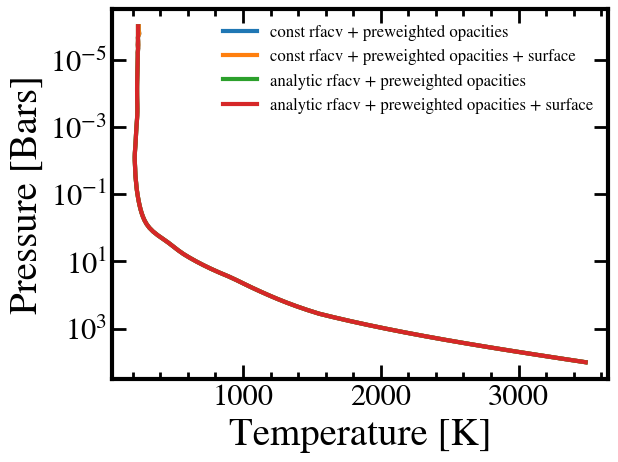

In [23]:
plt.semilogy(out_const_rfacv_preweighted['temperature'], out_const_rfacv_preweighted['pressure'], label="const rfacv + preweighted opacities")
plt.semilogy(out_const_rfacv_preweighted_surface['temperature'], out_const_rfacv_preweighted_surface['pressure'], label="const rfacv + preweighted opacities + surface")
plt.semilogy(out_analytic_rfacv_preweighted['temperature'], out_analytic_rfacv_preweighted['pressure'], label="analytic rfacv + preweighted opacities")
plt.semilogy(out_analytic_rfacv_preweighted_surface['temperature'], out_analytic_rfacv_preweighted_surface['pressure'], label="analytic rfacv + preweighted opacities + surface")

plt.ylabel("Pressure [Bars]")
plt.xlabel('Temperature [K]')
ax = plt.gca()
ax.invert_yaxis()
plt.legend()

How does including a surface change the rfacv values when running analytic heat redistribution?

In [24]:
# no surface
print('Analytic rfacv + no surface:', out_analytic_rfacv_preweighted['all_rfacv'])

# surface
print('\nAnalytic rfacv + surface:', out_analytic_rfacv_preweighted_surface['all_rfacv'])

Analytic rfacv + no surface: [0.50000017 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017
 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017
 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017
 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017
 0.50000017 0.50000017 0.50000017 0.50000016 0.50000016 0.50000016
 0.50000016 0.50000016 0.50000016 0.50000016 0.50000016 0.50000016
 0.50000016 0.50000016 0.50000016 0.50000016 0.50000016]

Analytic rfacv + surface: [0.50000017 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017
 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017
 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017
 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017 0.50000017
 0.50000017 0.50000017 0.50000017 0.50000016 0.50000016 0.50000016
 0.50000016 0.50000016 0.50000016 0.50000016 0.50000016 0.50000016
 0.50000016 0.50000016 0.50000016 0.50000016 0.50000016]


#

In [11]:
from numba import jit 

@jit(nopython=True)
def test(a):
    a = test1(a)
    return a


@jit(nopython=True)
def test1(a):
    return 1.0

In [10]:
test('HELLO')

[1.0]